In [1]:
import pandas as pd

In [2]:
refseq_metadata = pd.read_csv("assembly_summary.txt",sep='\t',skiprows=[0],dtype='str')

In [3]:
patric_metadata = pd.read_csv("genome_metadata",sep='\t',dtype='str')

In [4]:
patric_metadata.columns

Index(['genome_id', 'genome_name', 'organism_name', 'taxon_id',
       'genome_status', 'strain', 'serovar', 'biovar', 'pathovar', 'mlst',
       'other_typing', 'culture_collection', 'type_strain', 'completion_date',
       'publication', 'bioproject_accession', 'biosample_accession',
       'assembly_accession', 'genbank_accessions', 'refseq_accessions',
       'sequencing_centers', 'sequencing_status', 'sequencing_platform',
       'sequencing_depth', 'assembly_method', 'chromosomes', 'plasmids',
       'contigs', 'sequences', 'genome_length', 'gc_content', 'patric_cds',
       'brc1_cds', 'refseq_cds', 'isolation_site', 'isolation_source',
       'isolation_comments', 'collection_date', 'isolation_country',
       'geographic_location', 'latitude', 'longitude', 'altitude', 'depth',
       'other_environmental', 'host_name', 'host_gender', 'host_age',
       'host_health', 'body_sample_site', 'body_sample_subsite',
       'other_clinical', 'antimicrobial_resistance',
       'antimic

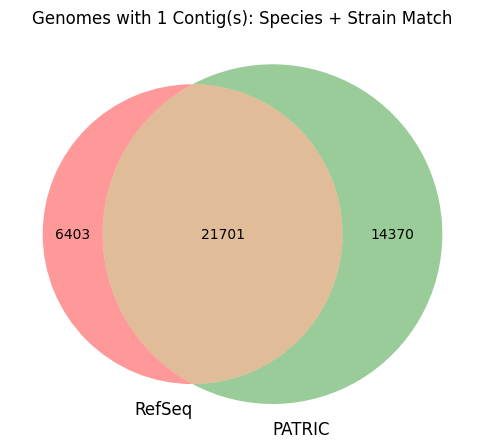

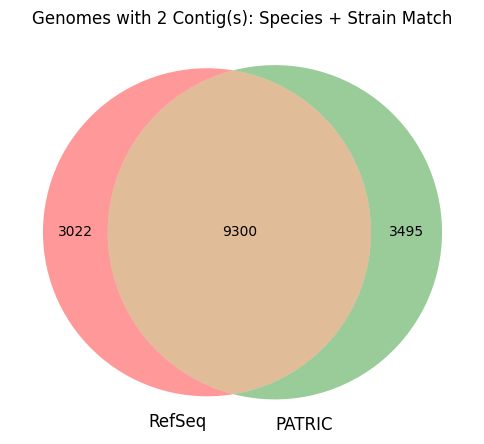

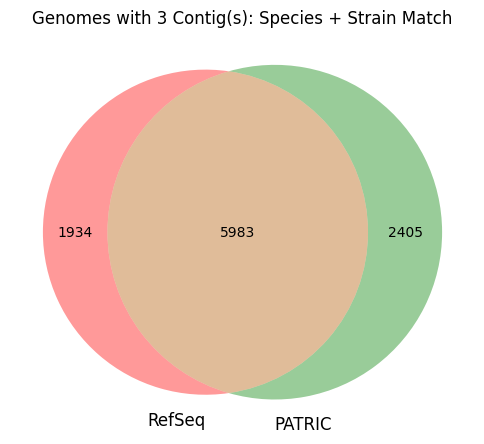

In [5]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# Load metadata
refseq_metadata = pd.read_csv("assembly_summary.txt", sep='\t', skiprows=[0], dtype='str')
patric_metadata = pd.read_csv("genome_metadata", sep='\t', dtype='str')

# Preprocessing: extract strain from infraspecific_name in RefSeq
def extract_strain(info):
    if pd.isna(info):
        return None
    if 'strain=' in info:
        return info.split('strain=')[-1].strip()
    return None

refseq_metadata['strain'] = refseq_metadata['infraspecific_name'].apply(extract_strain)

# Rename columns to align
refseq_metadata = refseq_metadata.rename(columns={'taxid': 'taxon_id', 'config_count': 'contigs'})
refseq_metadata['contig_count'] = pd.to_numeric(refseq_metadata['contig_count'], errors='coerce')
patric_metadata['contigs'] = pd.to_numeric(patric_metadata['contigs'], errors='coerce')

# Standardize strain: lowercase, remove punctuation/whitespace
def normalize_strain(s):
    if pd.isna(s):
        return None
    return ''.join(e for e in s.lower() if e.isalnum())

refseq_metadata['norm_strain'] = refseq_metadata['strain'].apply(normalize_strain)
patric_metadata['norm_strain'] = patric_metadata['strain'].apply(normalize_strain)

# For 1, 2, 3 contigs
for contig_num in [1, 2, 3]:
    # Subset based on contig count
    refseq_subset = refseq_metadata[refseq_metadata['contig_count'] == contig_num]
    patric_subset = patric_metadata[patric_metadata['contigs'] == contig_num]

    # Make sets of (species, strain) tuples
    refseq_genomes = set(zip(refseq_subset['taxon_id'], refseq_subset['norm_strain']))
    patric_genomes = set(zip(patric_subset['taxon_id'], patric_subset['norm_strain']))

    # Plot Venn diagram
    plt.figure(figsize=(6, 6))
    venn2([refseq_genomes, patric_genomes], set_labels=('RefSeq', 'PATRIC'))
    plt.title(f'Genomes with {contig_num} Contig(s): Species + Strain Match')
    plt.show()


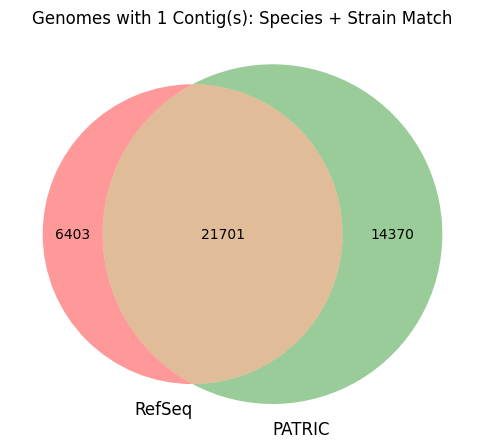

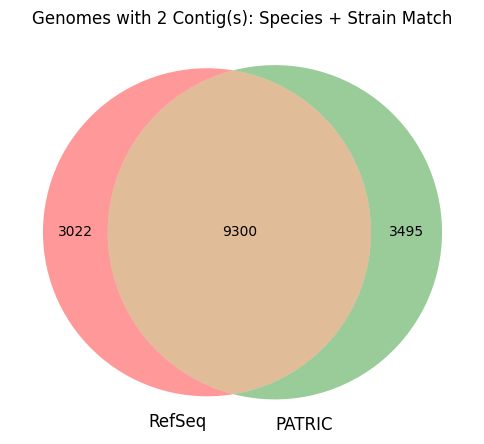

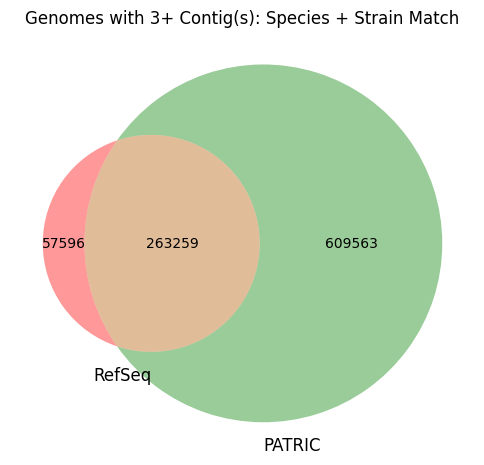

In [6]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# Load metadata
refseq_metadata = pd.read_csv("assembly_summary.txt", sep='\t', skiprows=[0], dtype='str')
patric_metadata = pd.read_csv("genome_metadata", sep='\t', dtype='str')

# Extract strain from infraspecific_name
def extract_strain(info):
    if pd.isna(info):
        return None
    if 'strain=' in info:
        return info.split('strain=')[-1].strip()
    return None

refseq_metadata['strain'] = refseq_metadata['infraspecific_name'].apply(extract_strain)

# Rename columns and convert contigs to numeric
refseq_metadata = refseq_metadata.rename(columns={'taxid': 'taxon_id', 'config_count': 'contig_count'})
refseq_metadata['contig_count'] = pd.to_numeric(refseq_metadata['contig_count'], errors='coerce')
patric_metadata['contigs'] = pd.to_numeric(patric_metadata['contigs'], errors='coerce')

# Normalize strain names
def normalize_strain(s):
    if pd.isna(s):
        return None
    return ''.join(e for e in s.lower() if e.isalnum())

refseq_metadata['norm_strain'] = refseq_metadata['strain'].apply(normalize_strain)
patric_metadata['norm_strain'] = patric_metadata['strain'].apply(normalize_strain)

# Loop for 1, 2, and 3+ contigs
for contig_num in [1, 2, '3+']:
    if contig_num == '3+':
        refseq_subset = refseq_metadata[refseq_metadata['contig_count'] >= 3]
        patric_subset = patric_metadata[patric_metadata['contigs'] >= 3]
        label = '3+'
    else:
        refseq_subset = refseq_metadata[refseq_metadata['contig_count'] == contig_num]
        patric_subset = patric_metadata[patric_metadata['contigs'] == contig_num]
        label = str(contig_num)

    # Build species-strain sets
    refseq_genomes = set(zip(refseq_subset['taxon_id'], refseq_subset['norm_strain']))
    patric_genomes = set(zip(patric_subset['taxon_id'], patric_subset['norm_strain']))

    # Plot
    plt.figure(figsize=(6, 6))
    venn2([refseq_genomes, patric_genomes], set_labels=('RefSeq', 'PATRIC'))
    plt.title(f'Genomes with {label} Contig(s): Species + Strain Match')
    plt.show()


In [7]:
#patric_metadata_filtered = patric_metadata[patric_metadata['refseq_accessions'].notna()]

In [8]:
#patric_metadata_filtered = patric_metadata[patric_metadata['genome_id'].isna()]


In [9]:
#refseq_metadata_filtered = refseq_metadata[refseq_metadata['#assembly_accession'].isna()]
   


In [10]:
patric_metadata['taxon_id'].value_counts()

taxon_id
562        58906
1773       42792
1313       29643
573        28495
1280       19675
           ...  
180856         1
483218         1
1232385        1
429581         1
136143         1
Name: count, Length: 104336, dtype: int64

In [11]:
refseq_metadata.head(1)

,#assembly_accession,bioproject,biosample,wgs_master,refseq_category,taxon_id,species_taxid,organism_name,infraspecific_name,isolate,...,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id,strain,norm_strain
0,GCF_036600855.1,PRJNA224116,SAMN38772065,JBAFXD000000000.1,na,7,7,Azorhizobium caulinodans,strain=CNM20190194,na,...,171,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-02-14,5320,5174,58,na,CNM20190194,cnm20190194


In [12]:
ecoli = patric_metadata[patric_metadata['taxon_id']=='91844']
g = ecoli[ecoli['strain']=='AF-CAI']
g[['genome_name','completion_date']]

,genome_name,completion_date
177889,Candidatus Portiera aleyrodidarum strain AF-CAI,2015-03-04T00:00:00Z
177894,Candidatus Portiera aleyrodidarum strain TV-BC...,2015-03-04T00:00:00Z


In [ ]:
ecoli = refseq_metadata[refseq_metadata['taxid']=='562']
ecoli['infraspecific_name'].value_counts().head(20)

infraspecific_name
na                             1435
strain=ST73                      16
strain=E2                        12
ecotype=Quinolone resistant      12
strain=EC2                       12
strain=EC1                       11
strain=EC11                      10
strain=EC3                       10
strain=EC14                      10
strain=10                         9
strain=2                          9
strain=15                         9
strain=EC12                       9
strain=EC13                       9
strain=E4                         9
strain=EC15                       9
strain=K-12                       8
strain=ECO3347                    8
strain=12                         8
strain=EC4                        8
Name: count, dtype: int64

In [ ]:
# Step 1: Filter by taxid 562 and strain 
df_taxid_562 = refseq_metadata[refseq_metadata['taxid'] == '562']
df_taxid_562 = df_taxid_562[df_taxid_562['infraspecific_name'] == 'strain=ST73']

# Step 2: Sort by the 'annotation_date' column (ensure it's in datetime format if necessary)
df_taxid_562['annotation_date'] = pd.to_datetime(df_taxid_562['annotation_date'])
df_taxid_562_sorted = df_taxid_562.sort_values(by='annotation_date', ascending=False)

# Step 3: Clean and convert 'genome_size' to numeric (if necessary)
df_taxid_562_sorted['genome_size'] = df_taxid_562_sorted['genome_size'].replace({r'[^\d.]': ''}, regex=True)
df_taxid_562_sorted['genome_size'] = pd.to_numeric(df_taxid_562_sorted['genome_size'], errors='coerce')

# Step 4: Select the latest assembly, and if there are still multiple rows, pick the one with the longest genome size
df_taxid_562_latest = df_taxid_562_sorted.iloc[0]  # Select the latest assembly
if len(df_taxid_562_sorted) > 1:
    df_taxid_562_latest = df_taxid_562_sorted.nlargest(1, 'genome_size')

df_taxid_562_latest


,#assembly_accession,bioproject,biosample,wgs_master,refseq_category,taxid,species_taxid,organism_name,infraspecific_name,isolate,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
79721,GCF_900536975.1,PRJNA224116,SAMEA104446543,UNQS00000000.1,na,562,562,Escherichia coli,strain=ST73,2009_3,...,0,138,138,NCBI RefSeq,GCF_900536975.1-RS_2024_06_17,2024-06-17,5338,4876,97,na


In [ ]:
refseq_metadata  = refseq_metadata[refseq_metadata['infraspecific_name']!='na']
refseq_metadata['infraspecific_name'].value_counts()

infraspecific_name
strain=MSSA                    240
strain=MRSA                    182
strain=BIOML-A1                 71
strain=S1                       66
strain=GPSC15 substr. ST191     59
                              ... 
strain=KC 131                    1
strain=IMAU11618                 1
strain=1W2                       1
strain=C3NV                      1
strain=BB002                     1
Name: count, Length: 329564, dtype: int64

In [ ]:
refseq_metadata['taxid'].value_counts()

taxid
562        36994
573        21100
1280       13208
287         9435
470         9414
           ...  
3391423        1
3391424        1
3391425        1
3391426        1
9              1
Name: count, Length: 79179, dtype: int64

In [ ]:
import pandas as pd

# Assuming 'refseq_metadata' is your DataFrame
def select_latest_assembly(group):
    # Sort by 'annotation_date' and convert to datetime if necessary
    group['annotation_date'] = pd.to_datetime(group['annotation_date'])
    group_sorted = group.sort_values(by='annotation_date', ascending=False)
    
    # Clean and convert 'genome_size' to numeric
    group_sorted['genome_size'] = group_sorted['genome_size'].replace({r'[^\d.]': ''}, regex=True)
    group_sorted['genome_size'] = pd.to_numeric(group_sorted['genome_size'], errors='coerce')
    
    # Select the latest assembly, and if there are still multiple rows, pick the one with the longest genome size
    latest_assembly = group_sorted.iloc[0]  # Select the latest assembly
    if len(group_sorted) > 1:
        latest_assembly = group_sorted.nlargest(1, 'genome_size').iloc[0]
    
    return latest_assembly

# Apply the function to each group (grouped by 'taxid' and 'infraspecific_name')
df_unique_assemblies = refseq_metadata.groupby(['taxid', 'infraspecific_name'], group_keys=False).apply(select_latest_assembly)

# The result will contain the unique assembly for each strain
df_unique_assemblies


In [ ]:
df_unique_assemblies['infraspecific_name'].value_counts()

infraspecific_name
strain=BIOML-A1      71
strain=BIOML-A2      53
strain=S1            49
strain=BIOML-A3      49
strain=C1            47
                     ..
strain=CCUG 60898     1
strain=TA208          1
strain=39T            1
strain=DSM 24617      1
strain=WGS1921        1
Name: count, Length: 329564, dtype: int64

In [ ]:
df_unique_assemblies.to_csv("refseq_representative_assemblies.csv")

In [ ]:
patric_metadata['strain'].value_counts()

strain
B31 5A4                   966
CO275                     769
Neisseria meningitidis    542
B31 5A3                   439
5A18NP1                   284
                         ... 
YR_bin-0414                 1
YR_bin-2355                 1
N43453                      1
N43451                      1
N43450                      1
Name: count, Length: 878075, dtype: int64

In [15]:
patric_metadata = patric_metadata[patric_metadata['strain']!='not applicable']
patric_metadata = patric_metadata[patric_metadata['strain']!='Not applicable']
patric_metadata = patric_metadata[patric_metadata['strain']!='Fecal samples']
patric_metadata = patric_metadata[patric_metadata['strain']!='not collected']

In [16]:
patric_metadata

,genome_id,genome_name,organism_name,taxon_id,genome_status,strain,serovar,biovar,pathovar,mlst,...,sporulation,temperature_range,optimal_temperature,salinity,oxygen_requirement,habitat,disease,comments,additional_metadata,norm_strain
0,469009.4,"""'Brassica napus' phytoplasma strain TW1""",NaN,469009,WGS,TW1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genome sequence of a strain of bacteria that c...,sample_type:metagenomic assembly;collected_by:...,tw1
1,1309411.5,"""'Deinococcus soli' Cha et al. 2014 strain N5""",NaN,1309411,Complete,N5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genome sequencing of a Gamma-Radiation-Resista...,sample_type:bacterial,n5
2,1123738.3,"""'Echinacea purpurea' witches'-broom phytoplas...",NaN,1123738,WGS,NCHU2014,NaN,NaN,NaN,NaN,...,NaN,NaN,C,NaN,NaN,NaN,NaN,'Echinacea purpurea' witches'-broom phytoplasm...,lab_host:Catharanthus roseus,nchu2014
3,551115.6,"""'Nostoc azollae' 0708""",'Nostoc azollae' 0708,551115,Complete,708,NaN,NaN,NaN,NaN,...,NaN,Mesophilic,-,NaN,Aerobic,Multiple,NaN,"Nostoc azollae 0708. Nostoc azollae 0708, also...",NaN,708
4,1856298.3,"""'Osedax' symbiont bacterium Rs2_46_30_T18 str...",NaN,1856298,WGS,Rs2_46_30_T18,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In this study, we simulate the Deepwater Horiz...",sample_type:metagenomic assembly,rs24630t18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059041,1131286.3,zeta proteobacterium SCGC AB-137-J06,zeta proteobacterium SCGC AB-137-J06,1131286,WGS,SCGC AB-137-J06,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single cell genome sequencing of biomineralizi...,NaN,scgcab137j06
1059042,1131287.3,zeta proteobacterium SCGC AB-602-C20,zeta proteobacterium SCGC AB-602-C20,1131287,WGS,SCGC AB-602-C20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single cell genome sequencing of biomineralizi...,NaN,scgcab602c20
1059043,1131288.3,zeta proteobacterium SCGC AB-602-E04,zeta proteobacterium SCGC AB-602-E04,1131288,WGS,SCGC AB-602-E04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single cell genome sequencing of biomineralizi...,NaN,scgcab602e04
1059044,1131289.3,zeta proteobacterium SCGC AB-604-B04,zeta proteobacterium SCGC AB-604-B04,1131289,WGS,SCGC AB-604-B04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single cell genome sequencing of biomineralizi...,NaN,scgcab604b04


In [ ]:
ensembl_metadata = pd.read_csv("species_EnsemblBacteria.txt",sep='\t',dtype='str')
ensembl_metadata

,#name,species,division,taxonomy_id,assembly,assembly_accession,genebuild,variation,microarray,pan_compara,peptide_compara,genome_alignments,other_alignments,core_db,species_id
[Actinobacillus] rossii (GCA_900444965),_actinobacillus_rossii_gca_900444965,EnsemblBacteria,123820,46338_E01,GCA_900444965.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_85_collection_core_61_114_1,244,NaN
[Arcobacter] porcinus str. 117434 (GCA_001695265),_arcobacter_porcinus_gca_001695265,EnsemblBacteria,1935204,ASM169526v1,GCA_001695265.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_15_collection_core_61_114_1,243,NaN
[Bacillus] caldolyticus str. reborg#228 (GCA_003595605),_bacillus_caldolyticus_gca_003595605,EnsemblBacteria,1394,ASM359560v1,GCA_003595605.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_109_collection_core_61_114_1,244,NaN
[Bacillus] selenitireducens MLS10 str. MLS-10 (GCA_000093085),_bacillus_selenitireducens_mls10_gca_000093085,EnsemblBacteria,439292,ASM9308v1,GCA_000093085.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_16_collection_core_61_114_1,244,NaN
[Bacillus] sp. KCTC 13219 (GCA_001592865),_bacillus_sp_kctc_13219_gca_001592865,EnsemblBacteria,1811976,KCTC_13210_a5,GCA_001592865.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_15_collection_core_61_114_1,244,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zymomonas mobilis subsp. mobilis ATCC 10988 (GCA_000175255),zymomonas_mobilis_subsp_mobilis_atcc_10988_gca...,EnsemblBacteria,555217,ASM17525v2,GCA_000175255.2,2022-12-Prokka,N,N,N,N,N,N,bacteria_89_collection_core_61_114_1,240,NaN
Zymomonas mobilis subsp. mobilis NRRL B-12526 str. NRRL B-12526(CICC 10225) (GCA_000576125),zymomonas_mobilis_subsp_mobilis_nrrl_b_12526_g...,EnsemblBacteria,1194424,ASM57612v1,GCA_000576125.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_21_collection_core_61_114_1,242,NaN
Zymomonas mobilis subsp. mobilis ZM4 = ATCC 31821 (GCA_000007105),zymomonas_mobilis_subsp_mobilis_zm4_atcc_31821...,EnsemblBacteria,264203,ASM710v1,GCA_000007105.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_1_collection_core_61_114_1,244,NaN
Zymomonas mobilis subsp. mobilis ZM4 = ATCC 31821 (GCA_003054575),zymomonas_mobilis_subsp_mobilis_zm4_atcc_31821...,EnsemblBacteria,264203,ASM305457v1,GCA_003054575.1,2022-12-Prokka,N,N,N,N,N,N,bacteria_90_collection_core_61_114_1,244,NaN


In [ ]:
ensembl = pd.read_xml("species_metadata_EnsemblBacteria.xml",parser="etree")
ensembl

,assembly_id,data_release_id,division,genebuild,has_genome_alignments,has_microarray,has_other_alignments,has_pan_compara,has_peptide_compara,has_synteny,...,website_packed,annotations,assembly,data_release,databases,features,organism,other_alignments,variations,compara
0,61114,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
1,13708,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
2,63278,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
3,17854,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
4,15646,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31327,18317,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
31328,23858,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
31329,1475,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None
31330,53556,78,EnsemblBacteria,2022-12-Prokka,0,0,0,0,0,NaN,...,0,NaN,\n,NaN,NaN,NaN,NaN,NaN,NaN,None


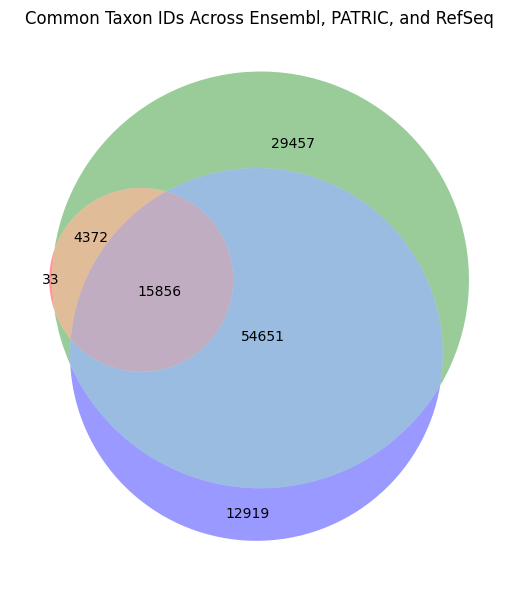

In [ ]:
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

#Replace these with your actual DataFrames if already loaded
ensembl_metadata = pd.read_csv("species_EnsemblBacteria.txt", sep='\t', dtype='str')
patric_metadata = pd.read_csv("genome_metadata", sep='\t', dtype='str')
refseq_metadata = pd.read_csv("assembly_summary.txt", sep='\t', skiprows=[0], dtype='str')

# Extract taxon IDs from each dataset
ensembl_taxa = set(ensembl_metadata['division'].dropna())
patric_taxa = set(patric_metadata['taxon_id'].dropna())
refseq_taxa = set(refseq_metadata['taxid'].dropna())

# Create Venn diagram
plt.figure(figsize=(8, 6))
venn3([ensembl_taxa, patric_taxa, refseq_taxa], 
      set_labels=('', '', ''))
plt.title("Common Taxon IDs Across Ensembl, PATRIC, and RefSeq")
plt.tight_layout()
plt.show()


In [ ]:
df_unique_assemblies_patric.to_csv("patric_representative_assemblies.csv")

In [ ]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


In [ ]:
import pandas as pd

# Assuming 'refseq_metadata' is your DataFrame
def select_latest_assembly(group):
    # Sort by 'annotation_date' and convert to datetime if necessary
    group['completion_date'] = pd.to_datetime(group['completion_date'])
    group_sorted = group.sort_values(by='completion_date', ascending=False)
    
    # Clean and convert 'genome_size' to numeric
    group_sorted['genome_length'] = group_sorted['genome_length'].replace({r'[^\d.]': ''}, regex=True)
    group_sorted['genome_length'] = pd.to_numeric(group_sorted['genome_length'], errors='coerce')
    
    # Select the latest assembly, and if there are still multiple rows, pick the one with the longest genome size
    latest_assembly = group_sorted.iloc[0]  # Select the latest assembly
    if len(group_sorted) > 1:
        latest_assembly = group_sorted.nlargest(1, 'genome_length').iloc[0]
    
    return latest_assembly

# Apply the function to each group (grouped by 'taxid' and 'infraspecific_name')
df_unique_assemblies_patric = patric_metadata.groupby(['taxon_id', 'strain'], group_keys=False).apply(select_latest_assembly)

# The result will contain the unique assembly for each strain
df_unique_assemblies_patric


In [ ]:
df_unique_assemblies_patric

genome_id  \
taxon_id strain                 
100      DSM 101       100.11   
         UV5            100.9   
100053   56159       100053.7   
         56640       100053.6   
         56643       100053.5   
...                       ...   
999894   HyVt-483   999894.10   
         S95         999894.9   
999898   CEB3        999898.5   
999931   39T         999931.5   
         DSM 24617   999931.3   

                                                          genome_name  \
taxon_id strain                                                         
100      DSM 101                Ancylobacter aquaticus strain DSM 101   
         UV5                        Ancylobacter aquaticus strain UV5   
100053   56159                     Leptospira alexanderi strain 56159   
         56640                     Leptospira alexanderi strain 56640   
         56643                     Leptospira alexanderi strain 56643   
...                                                               ...   
999894   HyVt-483        Thermosulfurimonas dismutans strain HyVt-483   
         S95                  Thermosulfurimonas dismutans strain S95   
999898   CEB3                           Peptococcaceae bacterium CEB3   
999931   39T        Barrientosiimonas humi strain type strain: 39 ...   
         DSM 24617            Barrientosiimonas humi strain DSM 24617   

                   organism_name taxon_id genome_status     strain serovar  \
taxon_id strain                                                              
100      DSM 101             NaN      100           WGS    DSM 101     NaN   
         UV5                 NaN      100           WGS        UV5     NaN   
100053   56159               NaN   100053           WGS      56159     NaN   
         56640               NaN   100053           WGS      56640     NaN   
         56643               NaN   100053           WGS      56643     NaN   
...                          ...      ...           ...        ...     ...   
999894   HyVt-483            NaN   999894           WGS   HyVt-483     NaN   
         S95                 NaN   999894           WGS        S95     NaN   
999898   CEB3                NaN   999898           WGS       CEB3     NaN   
999931   39T                 NaN   999931           WGS        39T     NaN   
         DSM 24617           NaN   999931           WGS  DSM 24617     NaN   

                   biovar pathovar mlst  ... motility sporulation  \
taxon_id strain                          ...                        
100      DSM 101      NaN      NaN  NaN  ...      NaN         NaN   
         UV5          NaN      NaN  NaN  ...      NaN         NaN   
100053   56159        NaN      NaN  NaN  ...      NaN         NaN   
         56640        NaN      NaN  NaN  ...      NaN         NaN   
         56643        NaN      NaN  NaN  ...      NaN         NaN   
...                   ...      ...  ...  ...      ...         ...   
999894   HyVt-483     NaN      NaN  NaN  ...      NaN         NaN   
         S95          NaN      NaN  NaN  ...      NaN         NaN   
999898   CEB3         NaN      NaN  NaN  ...      NaN         NaN   
999931   39T          NaN      NaN  NaN  ...      NaN         NaN   
         DSM 24617    NaN      NaN  NaN  ...      NaN         NaN   

                   temperature_range optimal_temperature salinity  \
taxon_id strain                                                     
100      DSM 101                 NaN                 NaN      NaN   
         UV5                     NaN                 NaN      NaN   
100053   56159                   NaN                 NaN      NaN   
         56640                   NaN                 NaN      NaN   
         56643                   NaN                 NaN      NaN   
...                              ...                 ...      ...   
999894   HyVt-483                NaN                 NaN      NaN   
         S95                     NaN                 NaN      NaN   
999898   CEB3                    NaN 

In [17]:
df_unique_assemblies_refseq = pd.read_csv("refseq_representative_assemblies.csv",dtype=str)

In [18]:
df_unique_assemblies_patric = pd.read_csv("patric_representative_assemblies.csv",dtype=str)

In [19]:
# Rename columns in the final result
df_unique_assemblies_refseq = df_unique_assemblies_refseq.rename(columns={'taxid': 'taxon_id', 'infraspecific_name': 'strain'})

# The result will now have 'taxon_id' and 'strain' as column names
df_unique_assemblies_refseq


,taxon_id,strain,#assembly_accession,bioproject,biosample,wgs_master,refseq_category,taxid.1,species_taxid,organism_name,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,100,strain=DSM 101,GCF_004339465.1,PRJNA224116,SAMN10866377,SMFY00000000.1,reference genome,100,100,Ancylobacter aquaticus,...,0,11,11,NCBI RefSeq,GCF_004339465.1-RS_2024_05_01,2024-05-01,4513,4381,53,na
1,100053,strain=56159,GCF_002009835.1,PRJNA224116,SAMN02947886,JQGT00000000.1,na,100053,100053,Leptospira alexanderi,...,0,337,337,NCBI RefSeq,GCF_002009835.1-RS_2024_07_26,2024-07-26,3803,3490,44,na
2,100053,strain=56640,GCF_002009825.1,PRJNA224116,SAMN02947769,JQGV00000000.1,na,100053,100053,Leptospira alexanderi,...,0,368,368,NCBI RefSeq,GCF_002009825.1-RS_2024_05_19,2024-05-19,3815,3462,46,na
3,100053,strain=56643,GCF_002009805.1,PRJNA224116,SAMN02947770,JQGU00000000.1,na,100053,100053,Leptospira alexanderi,...,0,335,335,NCBI RefSeq,GCF_002009805.1-RS_2024_07_26,2024-07-26,3786,3467,44,na
4,100053,strain=56650,GCF_002009775.1,PRJNA224116,SAMN02947771,JQGS00000000.1,na,100053,100053,Leptospira alexanderi,...,0,341,341,NCBI RefSeq,GCF_002009775.1-RS_2024_05_19,2024-05-19,3788,3476,42,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353843,999892,strain=P08,GCF_000204235.1,PRJNA224116,SAMN02471992,AFAM00000000.1,reference genome,999892,2559073,Cutibacterium modestum P08,...,0,22,22,NCBI RefSeq,GCF_000204235.1-RS_2024_03_28,2024-03-28,2500,2214,53,21571999
353844,999894,strain=S95,GCF_001652585.1,PRJNA224116,SAMN04623574,LWLG00000000.1,reference genome,999894,999894,Thermosulfurimonas dismutans,...,0,61,61,NCBI RefSeq,GCF_001652585.1-RS_2024_04_21,2024-04-21,2152,2077,55,na
353845,999931,strain=39T,GCF_910573815.1,PRJNA224116,SAMEA8751438,CAJTBP000000000.1,na,999931,999931,Barrientosiimonas humi,...,0,2,2,NCBI RefSeq,GCF_910573815.1-RS_2024_03_29,2024-03-29,3390,3319,56,na
353846,999931,strain=DSM 24617,GCF_006716095.1,PRJNA224116,SAMN11512942,VFOK00000000.1,reference genome,999931,999931,Barrientosiimonas humi,...,0,2,2,NCBI RefSeq,GCF_006716095.1-RS_2024_03_29,2024-03-29,3422,3354,56,na


In [20]:
# Remove "strain=" from every value in the 'strain' column
df_unique_assemblies_refseq['strain'] = df_unique_assemblies_refseq['strain'].str.replace('strain=', '', regex=False)

# The result will have "strain=" removed from the 'strain' column
df_unique_assemblies_refseq


,taxon_id,strain,#assembly_accession,bioproject,biosample,wgs_master,refseq_category,taxid.1,species_taxid,organism_name,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,100,DSM 101,GCF_004339465.1,PRJNA224116,SAMN10866377,SMFY00000000.1,reference genome,100,100,Ancylobacter aquaticus,...,0,11,11,NCBI RefSeq,GCF_004339465.1-RS_2024_05_01,2024-05-01,4513,4381,53,na
1,100053,56159,GCF_002009835.1,PRJNA224116,SAMN02947886,JQGT00000000.1,na,100053,100053,Leptospira alexanderi,...,0,337,337,NCBI RefSeq,GCF_002009835.1-RS_2024_07_26,2024-07-26,3803,3490,44,na
2,100053,56640,GCF_002009825.1,PRJNA224116,SAMN02947769,JQGV00000000.1,na,100053,100053,Leptospira alexanderi,...,0,368,368,NCBI RefSeq,GCF_002009825.1-RS_2024_05_19,2024-05-19,3815,3462,46,na
3,100053,56643,GCF_002009805.1,PRJNA224116,SAMN02947770,JQGU00000000.1,na,100053,100053,Leptospira alexanderi,...,0,335,335,NCBI RefSeq,GCF_002009805.1-RS_2024_07_26,2024-07-26,3786,3467,44,na
4,100053,56650,GCF_002009775.1,PRJNA224116,SAMN02947771,JQGS00000000.1,na,100053,100053,Leptospira alexanderi,...,0,341,341,NCBI RefSeq,GCF_002009775.1-RS_2024_05_19,2024-05-19,3788,3476,42,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353843,999892,P08,GCF_000204235.1,PRJNA224116,SAMN02471992,AFAM00000000.1,reference genome,999892,2559073,Cutibacterium modestum P08,...,0,22,22,NCBI RefSeq,GCF_000204235.1-RS_2024_03_28,2024-03-28,2500,2214,53,21571999
353844,999894,S95,GCF_001652585.1,PRJNA224116,SAMN04623574,LWLG00000000.1,reference genome,999894,999894,Thermosulfurimonas dismutans,...,0,61,61,NCBI RefSeq,GCF_001652585.1-RS_2024_04_21,2024-04-21,2152,2077,55,na
353845,999931,39T,GCF_910573815.1,PRJNA224116,SAMEA8751438,CAJTBP000000000.1,na,999931,999931,Barrientosiimonas humi,...,0,2,2,NCBI RefSeq,GCF_910573815.1-RS_2024_03_29,2024-03-29,3390,3319,56,na
353846,999931,DSM 24617,GCF_006716095.1,PRJNA224116,SAMN11512942,VFOK00000000.1,reference genome,999931,999931,Barrientosiimonas humi,...,0,2,2,NCBI RefSeq,GCF_006716095.1-RS_2024_03_29,2024-03-29,3422,3354,56,na


In [ ]:
df_unique_assemblies_patric.columns

Index(['taxon_id', 'strain', 'genome_id', 'genome_name', 'organism_name',
       'taxon_id.1', 'genome_status', 'strain.1', 'serovar', 'biovar',
       'pathovar', 'mlst', 'other_typing', 'culture_collection', 'type_strain',
       'completion_date', 'publication', 'bioproject_accession',
       'biosample_accession', 'assembly_accession', 'genbank_accessions',
       'refseq_accessions', 'sequencing_centers', 'sequencing_status',
       'sequencing_platform', 'sequencing_depth', 'assembly_method',
       'chromosomes', 'plasmids', 'contigs', 'sequences', 'genome_length',
       'gc_content', 'patric_cds', 'brc1_cds', 'refseq_cds', 'isolation_site',
       'isolation_source', 'isolation_comments', 'collection_date',
       'isolation_country', 'geographic_location', 'latitude', 'longitude',
       'altitude', 'depth', 'other_environmental', 'host_name', 'host_gender',
       'host_age', 'host_health', 'body_sample_site', 'body_sample_subsite',
       'other_clinical', 'antimicrobial_re

In [21]:
# Rename the index levels to 'name1' and 'name2'
df_patric_unique = df_unique_assemblies_patric.rename_axis(index={'taxon_id': 'name1', 'strain': 'name2'}).reset_index()
df_refseq_unique = df_unique_assemblies_refseq.rename_axis(index={'taxon_id': 'name1', 'strain': 'name2'}).reset_index()
# Assuming the two DataFrames are df1 and df2
common_taxon_strain = pd.merge(df_patric_unique[['taxon_id', 'strain']], df_refseq_unique[['taxon_id', 'strain']], 
                                on=['taxon_id', 'strain'], how='inner')

# The result will contain the common unique combinations of 'taxon_id' and 'strain'
common_taxon_strain




,taxon_id,strain
0,100,DSM 101
1,100053,56159
2,100053,56640
3,100053,56643
4,100053,56650
...,...,...
295050,999891,TA208
295051,999892,P08
295052,999894,S95
295053,999931,39T


In [22]:
# Perform the merge, keeping 'genome_id' from patric and 'ftp_path' from refseq
common_taxon_strain = pd.merge(
    df_patric_unique[['taxon_id', 'strain', 'genome_id','contigs']], 
    df_refseq_unique[['taxon_id', 'strain', 'ftp_path','contig_count']], 
    on=['taxon_id', 'strain'], 
    how='inner'
)

# The result will contain the common unique combinations of 'taxon_id' and 'strain'
# along with 'genome_id' from patric and 'ftp_path' from refseq
# Rename the 'contigs' column to 'contigs_patric'
common_taxon_strain = common_taxon_strain.rename(columns={'contigs': 'contigs_patric'})

# The result will have the 'contigs' column renamed to 'contigs_patric'
common_taxon_strain



,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
0,100,DSM 101,100.11,11,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11
1,100053,56159,100053.7,337,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,337
2,100053,56640,100053.6,368,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,368
3,100053,56643,100053.5,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,335
4,100053,56650,100053.4,341,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,341
...,...,...,...,...,...,...
295050,999891,TA208,999891.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1
295051,999892,P08,999892.3,22,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,22
295052,999894,S95,999894.9,61,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,61
295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2


In [40]:
res = pd.read_csv("all_bacteria_results.csv",dtype=str)
res = res.drop_duplicates(subset=['col6'])
res

,Unnamed: 0,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,subject_length,blast_output,n_of_-7,n_of_-6,n_of_-5,n_of_-4,n_of_-3,n_of_-2,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category
0,0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/248/435/GCF_000248435.2_ASM24843v2,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,1892857,1001534.3.fna_vs_GCF_000248435.2_ASM24843v2_genomic.fna_blast.xml,0,0,0,2,0,0,20,312,1868316,0,25,53,24129,0,0,1001534_subject_array_1739113446.bin,1892445,0.9997823396062143,95%
1,1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/248/415/GCF_000248415.2_ASM24841v2,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,1968610,1001542.3.fna_vs_GCF_000248415.2_ASM24841v2_genomic.fna_blast.xml,0,0,0,2,0,0,16,0,1968488,0,23,52,29,0,0,1001542_subject_array_1739113448.bin,1968517,0.9999527585453696,95%
2,2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/204/295/GCF_000204295.1_ASM20429v1,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,5434353,1001585.3.fna_vs_GCF_000204295.1_ASM20429v1_genomic.fna_blast.xml,0,0,0,0,0,0,0,0,5434353,0,0,0,0,0,0,1001585_subject_array_1739113452.bin,5434353,1.0,100%
3,3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/008/931/305/GCF_008931305.1_ASM893130v1,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,8667664,100226.137.fna_vs_GCF_008931305.1_ASM893130v1_genomic.fna_blast.xml,0,0,0,0,0,0,0,0,8667664,0,0,0,0,0,0,100226_subject_array_1739113458.bin,8667664,1.0,100%
4,4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/195/085/GCF_000195085.1_ASM19508v1,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,1284727,1002672.3.fna_vs_GCF_000195085.1_ASM19508v1_genomic.fna_blast.xml,0,0,0,0,0,0,0,0,1284727,0,0,0,0,0,0,1002672_subject_array_1739113459.bin,1284727,1.0,100%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238452,46719,218394,562,SM EMB CIPRO 1,562.108591,165,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/024/608/045/GCF_024608045.1_ASM2460804v1,165,562.108591.fna,GCF_024608045.1_ASM2460804v1_genomic.fna,5039113,5039113,562.108591.fna_vs_GCF_024608045.1_ASM2460804v1_genomic.fna_blast.xml,0,0,0,0,0,0,0,0,5039113,0,0,0,0,0,0,562_subject_array_1743261076.bin,5039113,1.0,100%
238453,46720,218395,562,SM EMB CIPRO 3,562.108586,163,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/024/607/985/GCF_024607985.1_ASM2460798v1,163,562.108586.fna,GCF_024607985.1_ASM2460798v1_genomic.fna,5055014,5055014,562.108586.fna_vs_GCF_024607985.1_ASM2460798v1_genomic.fna_blast.xml,0,0,0,0,0,0,1,0,5055013,0,0,0,0,0,0,562_subject_array_1743261079.bin,5055013,0.9999998021766112,95%
238454,46721,218396,562,SM EMB CIPRO 4,562.108584,175,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/024/607/965/GCF_024607965.1_ASM2460796v1,175,562.108584.fna,GCF_024607965.1_ASM2460796v1_genomic.fna,5037564,5037564,562.108584.fna_vs_GCF_024607965.1_ASM2460796v1_genomic.fna_blast.xml,0,0,0,0,0,0,0,0,5037564,0,0,0,0,0,0,562_subject_array_1743261083.bin,5037564,1.0,100%
238455,46722,218397,562,SM EMB CIPRO 5,562.108788,155,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/024/720/775/GCF_024720775.1_ASM2472077v1,155,562.108788.fna,GCF_024720775.1_ASM2472077v1_genomic.fna,4962872,4962872,562.108788.fna_vs_GCF_024720775.1_ASM2472077v1_genomic.fna_blast.xml,0,0,0,0,0,0,1,0,4962868,0,1,2,0,0,0,562_subject_array_1743261086.bin,4962868,0.9999991940150784,95%


In [41]:
res[res['ratio_category']=='50%']

,Unnamed: 0,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,subject_length,blast_output,n_of_-7,n_of_-6,n_of_-5,n_of_-4,n_of_-3,n_of_-2,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename,n_total,ratio,ratio_category
5211,5211,91476,1653831,CARBpar,1653831.38,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/014/252/255/GCF_014252255.1_ASM1425225v1,1,1653831.38.fna,GCF_014252255.1_ASM1425225v1_genomic.fna,561052,628934,1653831.38.fna_vs_GCF_014252255.1_ASM1425225v1_genomic.fna_blast.xml,0,0,0,533,0,0,4503,217808,322193,0,7305,76592,0,0,0,1653831_subject_array_1739126230.bin,322193,0.5122842778415542,50%
39747,673,82088,159,Bhyo_247,159.376,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/027/586/275/GCF_027586275.1_ASM2758627v1,5,159.376.fna,GCF_027586275.1_ASM2758627v1_genomic.fna,1603283,3271490,159.376.fna_vs_GCF_027586275.1_ASM2758627v1_genomic.fna_blast.xml,0,0,289,79,0,0,309,1574203,1651840,0,465,6962,37053,0,290,159_subject_array_1739489942.bin,1688893,0.5162458084848188,50%
39748,674,82095,159,Bhyo_259,159.369,5,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/027/586/085/GCF_027586085.1_ASM2758608v1,5,159.369.fna,GCF_027586085.1_ASM2758608v1_genomic.fna,1544053,3218019,159.369.fna_vs_GCF_027586085.1_ASM2758608v1_genomic.fna_blast.xml,0,0,317,62,0,0,273,1578554,1585118,0,448,6379,46398,0,470,159_subject_array_1739489943.bin,1631516,0.5069938990416154,50%
49761,932,165456,2975056,LMG 31809,2975056.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/027/920/805/GCF_027920805.1_ASM2792080v1,10,2975056.3.fna,GCF_027920805.1_ASM2792080v1_genomic.fna,1673018,3212657,2975056.3.fna_vs_GCF_027920805.1_ASM2792080v1_genomic.fna_blast.xml,0,0,213,47,0,0,152,1521219,1680147,0,239,1604,8752,0,284,2975056_subject_array_1739893264.bin,1688899,0.5257016232980988,50%
49772,943,166209,2984211,LKC15W,2984211.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/028/550/435/GCF_028550435.1_ASM2855043v1,10,2984211.3.fna,GCF_028550435.1_ASM2855043v1_genomic.fna,1911806,3776254,2984211.3.fna_vs_GCF_028550435.1_ASM2855043v1_genomic.fna_blast.xml,0,0,107,18,0,0,57,1847868,1917673,0,53,2382,7966,0,130,2984211_subject_array_1739893282.bin,1925639,0.5099336538273114,50%
50834,684,763,102684,AF94-18M2BA,102684.46,12,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/027/664/625/GCF_027664625.1_ASM2766462v1,12,102684.46.fna,GCF_027664625.1_ASM2766462v1_genomic.fna,969343,1838625,102684.46.fna_vs_GCF_027664625.1_ASM2766462v1_genomic.fna_blast.xml,0,0,22,5,0,0,7,864889,970171,0,4,809,2688,0,30,102684_subject_array_1741029872.bin,972859,0.5291231218981576,50%
60543,10393,11658,1218564,80-412,1218564.3,1377,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/332/555/GCF_000332555.2_gls454193v02,67,1218564.3.fna,GCF_000332555.2_gls454193v02_genomic.fna,2433936,4437303,1218564.3.fna_vs_GCF_000332555.2_gls454193v02_genomic.fna_blast.xml,0,0,1490,229,0,0,1385,2010752,1161563,0,1719,12672,1245629,0,1864,1218564_subject_array_1741062248.bin,2407192,0.5424898863115726,50%
61171,11021,12331,1235461,GR4,1235461.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/320/385/GCF_000320385.2_ASM32038v2,5,1235461.3.fna,GCF_000320385.2_ASM32038v2_genomic.fna,3618794,7141709,1235461.3.fna_vs_GCF_000320385.2_ASM32038v2_genomic.fna_blast.xml,0,0,317,78,1,0,326,3407321,3674938,0,442,10704,47210,0,372,1235461_subject_array_1741064105.bin,3722148,0.5211844951957577,50%
61404,11254,12671,1242989,1342KT,1242989.3,1149,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/332/395/GCF_000332395.2_gls454048v02,68,1242989.3.fna,GCF_000332395.2_gls454048v02_genomic.fna,2034136,3987811,1242989.3.fna_vs_GCF_000332395.2_gls454048v02_genomic.fna_blast.xml,0,0,1286,180,0,0,1459,1919983,1037527,0,1575,9120,1015144,0,1537,1242989_subject_array_1741064933.bin,2052671,0.514736280129625,50%
61981,11831,13360,1254,BSD3448080978st1_B8_BSD3448080978_160613,1254.718,15,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/028/328/175/GCF_028328175.1_ASM2832817v1,15,1254.718.fna,GCF_0

In [35]:

pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 0)            # Disable line wrapping
pd.set_option('display.max_colwidth', None)  # Show full content in each cell


mis = common_taxon_strain[~common_taxon_strain['ftp_path'].isin(res['col6'])].copy()
mis


,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
101,1002526,FZJ,1002526.10,21,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/033/991/595/GCF_033991595.1_ASM3399159v1,21
110,1003,"GEY, DSM 9560",1003.8,123,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900/113/045/GCF_900113045.1_IMG-taxon_2636415974_annotated_assembly,123
115,1003114,SNNU513,1003114.4,3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/037/027/415/GCF_037027415.1_ASM3702741v1,3
369,1008,WH,1008.12,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/027/594/745/GCF_027594745.1_ASM2759474v1,2
384,100884,RTP31083st1_B1_RTP31083_211112,100884.46,127,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/039/752/815/GCF_039752815.1_ASM3975281v1,127
...,...,...,...,...,...,...
295046,999627,CGMCC 1.10959,999627.3,90,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900/116/455/GCF_900116455.1_IMG-taxon_2667527411_annotated_assembly,90
295048,999699,JA575,999699.4,69,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/003/385/925/GCF_003385925.1_ASM338592v1,69
295049,999700,"JA576,NBRC 108863,KCTC 15144",999700.3,69,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/003/387/125/GCF_003387125.1_ASM338712v1,69
295051,999892,P08,999892.3,22,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/204/235/GCF_000204235.1_ASM20423v2,22


In [ ]:
# First DataFrame where contigs_patric = "1" and contig_count = "1"
df_contigs_one = common_taxon_strain[(common_taxon_strain['contigs_patric'] == "10") & 
                                     (common_taxon_strain['contig_count'] == "10")]

# Second DataFrame containing the remaining rows
df_remaining = common_taxon_strain[~((common_taxon_strain['contigs_patric'] == "10") & 
                                     (common_taxon_strain['contig_count'] == "10"))]

# df_contigs_one contains rows where contigs_patric = "1" and contig_count = "1"
# df_remaining contains the remaining rows
df_contigs_one


,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
28,1001583,KB290,1001583.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
89,1002227,VKM B-2663,1002227.6,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
772,1017270,NIO-1003,1017270.12,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,10
1021,1034769,HW567,1034769.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
1052,1036177,NC8,1036177.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
...,...,...,...,...,...,...
294244,985002,CFSA17SA054,985002.353,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
294615,992037,Hp A-20,992037.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
295017,999423,F0473,999423.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10
295037,999544,DSM 45548,999544.3,10,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,10


In [ ]:
df_contigs_one.to_csv("genomes.csv")

In [ ]:
df_remaining.to_csv("common_strains_with_multiple_contigs.csv")
df_contigs_one.to_csv("common_strains_with_one_contig.csv")

In [ ]:
df_remaining

,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
0,100,DSM 101,100.11,11,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11
1,100053,56159,100053.7,337,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,337
2,100053,56640,100053.6,368,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,368
3,100053,56643,100053.5,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,335
4,100053,56650,100053.4,341,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,341
...,...,...,...,...,...,...
295049,999700,"JA576,NBRC 108863,KCTC 15144",999700.3,69,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,69
295051,999892,P08,999892.3,22,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,22
295052,999894,S95,999894.9,61,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,61
295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2


In [ ]:
import pandas as pd
df = pd.read_csv("results/output_file.csv",dtype=str)
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,20,312,1868316,0,25,53,24129,0,0,1001534_subject_array_1739113446.bin
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,16,0,1968488,0,23,52,29,0,0,1001542_subject_array_1739113448.bin
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,0,0,5434353,0,0,0,0,0,0,1001585_subject_array_1739113452.bin
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,0,0,8667664,0,0,0,0,0,0,100226_subject_array_1739113458.bin
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,0,0,1284727,0,0,0,0,0,0,1002672_subject_array_1739113459.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,0,99,2190557,0,0,0,0,0,0,99822_subject_array_1739184665.bin
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,0,0,2201894,0,0,0,0,0,0,99822_subject_array_1739184667.bin
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,0,99,2432471,0,0,0,0,0,0,99822_subject_array_1739184669.bin
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,0,0,1873758,0,0,0,0,0,0,999183_subject_array_1739184670.bin


In [ ]:
df1 = pd.read_csv("/Users/gboldirev1/genome_metadata",sep='\t',dtype=str)
df1
df2 = pd.read_csv("/Users/gboldirev1/assembly_summary.txt",sep='\t',dtype=str,skiprows=1)


In [ ]:
merged_df = pd.merge(df, df2, left_on='col6', right_on='ftp_path', how='inner')


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-03-05,1950,1736,52,22535949
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,1,1,1,NCBI RefSeq,GCF_000248415.2-RS_2024_03_27,2024-03-27,2040,1823,53,22535949
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,1,1,1,NCBI RefSeq,GCF_000204295.1-RS_2024_10_21,2024-10-21,5115,5002,82,21551299
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,1,1,1,NCBI RefSeq,GCF_008931305.1-RS_2024_03_22,2024-03-22,7853,7582,87,31548381
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,1,1,1,NCBI RefSeq,GCF_000195085.1-RS_2024_03_31,2024-03-31,1434,1385,38,21515764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,1,1,1,NCBI RefSeq,GCF_009650275.1-RS_2024_05_06,2024-05-06,2162,1994,91,na
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-02-13,2218,2011,89,na
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,1,1,1,NCBI RefSeq,GCF_009650295.1-RS_2024_05_06,2024-05-06,2486,2277,90,na
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,1,1,1,NCBI RefSeq,GCF_029625435.1-RS_2024_04_08,2024-04-08,1691,1621,61,na


In [ ]:
filtered_df = merged_df[merged_df['assembly_level'] == 'Complete Genome']
filtered_df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-03-05,1950,1736,52,22535949
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,1,1,1,NCBI RefSeq,GCF_000248415.2-RS_2024_03_27,2024-03-27,2040,1823,53,22535949
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,1,1,1,NCBI RefSeq,GCF_000204295.1-RS_2024_10_21,2024-10-21,5115,5002,82,21551299
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,1,1,1,NCBI RefSeq,GCF_008931305.1-RS_2024_03_22,2024-03-22,7853,7582,87,31548381
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,1,1,1,NCBI RefSeq,GCF_000195085.1-RS_2024_03_31,2024-03-31,1434,1385,38,21515764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20642,294969,99807,DSM 44609,99807.17,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99807.17.fna,GCF_030408435.1_ASM3040843v1_genomic.fna,2599172,...,1,1,1,NCBI RefSeq,GCF_030408435.1-RS_2024_07_07,2024-07-07,2206,2101,62,na
20643,294970,998088,B565,998088.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,998088.4.fna,GCF_000204115.1_ASM20411v1_genomic.fna,4551783,...,1,1,1,NCBI RefSeq,GCF_000204115.1-RS_2024_03_20,2024-03-20,4201,4032,139,21551296
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-02-13,2218,2011,89,na
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,1,1,1,NCBI RefSeq,GCF_029625435.1-RS_2024_04_08,2024-04-08,1691,1621,61,na


In [ ]:
merged_d = pd.merge(df, df1, left_on='col4', right_on='genome_id', how='inner')
merged_d

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,motility,sporulation,temperature_range,optimal_temperature,salinity,oxygen_requirement,habitat,disease,comments,additional_metadata
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TI0902.This strain will...,NaN
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TIGB03.This strain is a...,NaN
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,This strain will be used for comparative analy...,NaN
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genome sequencing of Streptomyces coelicolor C...,sample_type:cell culture
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,Genomic DNA from Strain IMCC9063 from SAR11 gr...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.sanger.ac.uk/resources/downloads/ba...,NaN
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sample_type:bacterial isolate;collected_by:Ell...


In [ ]:
df_c = merged_d[merged_d['genome_status'] == 'Complete']
df_c


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,motility,sporulation,temperature_range,optimal_temperature,salinity,oxygen_requirement,habitat,disease,comments,additional_metadata
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TI0902.This strain will...,NaN
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TIGB03.This strain is a...,NaN
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,This strain will be used for comparative analy...,NaN
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genome sequencing of Streptomyces coelicolor C...,sample_type:cell culture
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,Genomic DNA from Strain IMCC9063 from SAR11 gr...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.sanger.ac.uk/resources/downloads/ba...,NaN
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sample_type:bacterial isolate;collected_by:Ell...


In [ ]:
df_c

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,motility,sporulation,temperature_range,optimal_temperature,salinity,oxygen_requirement,habitat,disease,comments,additional_metadata
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TI0902.This strain will...,NaN
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Francisella tularensis TIGB03.This strain is a...,NaN
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,This strain will be used for comparative analy...,NaN
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genome sequencing of Streptomyces coelicolor C...,sample_type:cell culture
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,Genomic DNA from Strain IMCC9063 from SAR11 gr...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.sanger.ac.uk/resources/downloads/ba...,NaN
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comparative Genomic Analysis of the Streptococ...,collected_by:SGH
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sample_type:bacterial isolate;collected_by:Ell...


In [ ]:
filtered_df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-03-05,1950,1736,52,22535949
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,1,1,1,NCBI RefSeq,GCF_000248415.2-RS_2024_03_27,2024-03-27,2040,1823,53,22535949
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,1,1,1,NCBI RefSeq,GCF_000204295.1-RS_2024_10_21,2024-10-21,5115,5002,82,21551299
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,1,1,1,NCBI RefSeq,GCF_008931305.1-RS_2024_03_22,2024-03-22,7853,7582,87,31548381
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,1,1,1,NCBI RefSeq,GCF_000195085.1-RS_2024_03_31,2024-03-31,1434,1385,38,21515764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20642,294969,99807,DSM 44609,99807.17,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99807.17.fna,GCF_030408435.1_ASM3040843v1_genomic.fna,2599172,...,1,1,1,NCBI RefSeq,GCF_030408435.1-RS_2024_07_07,2024-07-07,2206,2101,62,na
20643,294970,998088,B565,998088.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,998088.4.fna,GCF_000204115.1_ASM20411v1_genomic.fna,4551783,...,1,1,1,NCBI RefSeq,GCF_000204115.1-RS_2024_03_20,2024-03-20,4201,4032,139,21551296
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-02-13,2218,2011,89,na
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,1,1,1,NCBI RefSeq,GCF_029625435.1-RS_2024_04_08,2024-04-08,1691,1621,61,na


In [ ]:
results = pd.merge(df_c, filtered_df, on='col6', how='inner')
results.to_csv("complete_labeled_genomes.csv")


In [ ]:
results

,col1_x,col2_x,col3_x,col4_x,col5_x,col6,col7_x,query_fna_x,subject_fna_x,query_length_x,...,replicon_count,scaffold_count,contig_count,annotation_provider,annotation_name,annotation_date,total_gene_count,protein_coding_gene_count,non_coding_gene_count,pubmed_id
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-03-05,1950,1736,52,22535949
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,1,1,1,NCBI RefSeq,GCF_000248415.2-RS_2024_03_27,2024-03-27,2040,1823,53,22535949
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,1,1,1,NCBI RefSeq,GCF_000204295.1-RS_2024_10_21,2024-10-21,5115,5002,82,21551299
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,1,1,1,NCBI RefSeq,GCF_008931305.1-RS_2024_03_22,2024-03-22,7853,7582,87,31548381
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,1,1,1,NCBI RefSeq,GCF_000195085.1-RS_2024_03_31,2024-03-31,1434,1385,38,21515764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15941,294969,99807,DSM 44609,99807.17,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99807.17.fna,GCF_030408435.1_ASM3040843v1_genomic.fna,2599172,...,1,1,1,NCBI RefSeq,GCF_030408435.1-RS_2024_07_07,2024-07-07,2206,2101,62,na
15942,294970,998088,B565,998088.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,998088.4.fna,GCF_000204115.1_ASM20411v1_genomic.fna,4551783,...,1,1,1,NCBI RefSeq,GCF_000204115.1-RS_2024_03_20,2024-03-20,4201,4032,139,21551296
15943,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,1,1,1,NCBI RefSeq,NCBI Prokaryotic Genome Annotation Pipeline (P...,2024-02-13,2218,2011,89,na
15944,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,1,1,1,NCBI RefSeq,GCF_029625435.1-RS_2024_04_08,2024-04-08,1691,1621,61,na


In [ ]:
df

,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
0,25,1001534,TI0902,1001534.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001534.3.fna,GCF_000248435.2_ASM24843v2_genomic.fna,1892744,...,20,312,1868316,0,25,53,24129,0,0,1001534_subject_array_1739113446.bin
1,26,1001542,TIGB03,1001542.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001542.3.fna,GCF_000248415.2_ASM24841v2_genomic.fna,1968651,...,16,0,1968488,0,23,52,29,0,0,1001542_subject_array_1739113448.bin
2,29,1001585,NK-01,1001585.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1001585.3.fna,GCF_000204295.1_ASM20429v1_genomic.fna,5434353,...,0,0,5434353,0,0,0,0,0,0,1001585_subject_array_1739113452.bin
3,92,100226,CFB_NBC_0001,100226.137,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,100226.137.fna,GCF_008931305.1_ASM893130v1_genomic.fna,8667664,...,0,0,8667664,0,0,0,0,0,0,100226_subject_array_1739113458.bin
4,103,1002672,IMCC9063,1002672.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,1002672.3.fna,GCF_000195085.1_ASM19508v1_genomic.fna,1284727,...,0,0,1284727,0,0,0,0,0,0,1002672_subject_array_1739113459.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20646,294973,99822,DB60705-15,99822.28,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.28.fna,GCF_009650275.1_ASM965027v1_genomic.fna,2190656,...,0,99,2190557,0,0,0,0,0,0,99822_subject_array_1739184665.bin
20647,294975,99822,NCTC4669,99822.25,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,1,99822.25.fna,GCF_900635345.1_41686_B01_genomic.fna,2201894,...,0,0,2201894,0,0,0,0,0,0,99822_subject_array_1739184667.bin
20648,294989,99822,STREP97-15,99822.29,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,99822.29.fna,GCF_009650295.1_ASM965029v1_genomic.fna,2432570,...,0,99,2432471,0,0,0,0,0,0,99822_subject_array_1739184669.bin
20649,294996,999183,DSM 25104,999183.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1,999183.3.fna,GCF_029625435.1_ASM2962543v1_genomic.fna,1873758,...,0,0,1873758,0,0,0,0,0,0,999183_subject_array_1739184670.bin


In [ ]:
merged_results = pd.merge(results, df, on='col6', how='inner')
merged_results.to_csv("complete_labeled_genomes.csv")

In [ ]:
df = pd.read_csv("/Users/gboldirev1/common_strains_with_multiple_contigs.csv",dtype=str)
df

,Unnamed: 0,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
0,0,100,DSM 101,100.11,11,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11
1,1,100053,56159,100053.7,337,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,337
2,2,100053,56640,100053.6,368,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,368
3,3,100053,56643,100053.5,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,335
4,4,100053,56650,100053.4,341,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,341
...,...,...,...,...,...,...,...
273941,295049,999700,"JA576,NBRC 108863,KCTC 15144",999700.3,69,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,69
273942,295051,999892,P08,999892.3,22,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,22
273943,295052,999894,S95,999894.9,61,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,61
273944,295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2


In [ ]:
import pandas as pd

# List of file paths
file_paths = [
    "results/2to2results.csv",
    "results/output_file_3.csv",
    "results/output_file_4.csv",
    "results/output_file_5.csv",
    "results/output_file_6.csv",
    "results/output_file_7.csv",
    "results/output_file_8.csv",
    "results/output_file_9.csv",
    "results/output_file_10.csv"
]

# Load the main DataFrame
df = pd.read_csv("/Users/gboldirev1/common_strains_with_multiple_contigs.csv", dtype=str)

# Iterate over each file, find common 'ftp_path' values, and remove them
for file_path in file_paths:
    try:
        temp_df = pd.read_csv(file_path, dtype=str)  # Load the file
        if 'ftp_path' in temp_df.columns:  # Ensure 'ftp_path' column exists
            df = df[~df['ftp_path'].isin(temp_df['ftp_path'])]  # Remove common 'ftp_path'
    except FileNotFoundError:
        print(f"Warning: File not found - {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")




,Unnamed: 0,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
0,0,100,DSM 101,100.11,11,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11
1,1,100053,56159,100053.7,337,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,337
2,2,100053,56640,100053.6,368,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,368
3,3,100053,56643,100053.5,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,335
4,4,100053,56650,100053.4,341,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,341
...,...,...,...,...,...,...,...
273941,295049,999700,"JA576,NBRC 108863,KCTC 15144",999700.3,69,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,69
273942,295051,999892,P08,999892.3,22,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,22
273943,295052,999894,S95,999894.9,61,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,61
273944,295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2


In [ ]:
import pandas as pd

# List of file paths
file_paths = [
    "results/2to2results.csv",
    "results/output_file_3.csv",
    "results/output_file_4.csv",
    "results/output_file_5.csv",
    "results/output_file_6.csv",
    "results/output_file_7.csv",
    "results/output_file_8.csv",
    "results/output_file_9.csv",
    "results/output_file_10.csv"
]

# Load the main DataFrame
df = pd.read_csv("/Users/gboldirev1/common_strains_with_multiple_contigs.csv", dtype=str)

# Iterate over each file, find common 'ftp_path' values, and remove them
for file_path in file_paths:
    try:
        temp_df = pd.read_csv(file_path, usecols=[5], dtype=str, header=None)  # Load only column 6
        temp_df.columns = ['ftp_path']  # Rename column for consistency
        df = df[~df['ftp_path'].isin(temp_df['ftp_path'])]  # Remove common ftp_path values
    except FileNotFoundError:
        print(f"Warning: File not found - {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

df.to_csv("remaining_genomes.csv")
